In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [4]:
df = pd.read_csv("data_sintetica/datos_sinteticos_ml_v2.csv")
df

,Edad,hosteleria_restaurante,hosteleria_asador,hosteleria_sidreria,hosteleria_bodega,hosteleria_queseria,Gourmet_Agricultura_ecologica,Gourmet_Denominacion_de_Origen,Gourmet_Eusko_Label,Gourmet_Euskal_Baserri,...,local_sidreria,local_bodega,local_queseria,local_bizkaia,local_gipuzkoa,local_alava,sol,estrella,q,local_valoracion
0,70,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,1,0,0,0,4.1
1,67,0,1,0,1,1,0,1,1,1,...,0,0,0,0,1,0,0,1,0,4.4
2,57,0,1,0,1,1,0,0,0,0,...,0,1,0,0,0,1,0,0,1,3.9
3,54,1,1,1,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,4.6
4,57,1,1,0,0,1,1,1,1,1,...,0,0,0,1,0,0,0,1,0,4.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,48,0,0,0,1,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,4.7
1996,45,1,1,1,0,0,0,0,0,1,...,0,0,0,1,0,0,0,1,0,4.4
1997,60,1,1,0,0,0,1,1,1,1,...,0,0,0,0,1,0,0,0,1,4.7
1998,55,0,1,0,1,1,0,1,0,1,...,0,1,0,1,0,0,0,0,0,4.1


In [3]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

def eda(df, target=None):
    """
        Realiza un EDA automático visual.
    """
    
    # 1. MUESTRA
    print('='*100)
    display(Markdown("### 📋 Muestra"))
    display(df.head()) # Head es suficiente y más rápido
    
    # 2. INFO
    print('='*100)
    display(Markdown(f"### 📊 Info → `{df.shape[0]:,}` filas × `{df.shape[1]}` columnas"))
    # df.info() puede ser muy lento en consola, mejor mostrar dtypes resumidos si es gigante
    # Pero lo dejo como pediste:
    print(df.info())
    display(Markdown('#### Uniques'))
    print(df.nunique())
    
    # 3. NULOS
    print('='*100)
    display(Markdown("### ⚠️ Null & NaN"))
    print(df.isna().sum())
    # Mostrar solo las filas con nulos si no son demasiadas, para no colgar el notebook
    null_rows = df[df.isnull().any(axis=1)]
    if len(null_rows) > 0:
        display(null_rows.head())
    
    # 4. BOXPLOTS (Solo numéricas)
    print('='*100)
    display(Markdown("### 📦 Describe"))
    display(df.describe().round(3))
    
    cols = df.describe().columns
    n = len(cols)

    if n > 0:
        # Crear rejilla
        fig, axes = plt.subplots(nrows=(n//3)+1, ncols=3, figsize=(15, 5*((n//3)+1)))
        axes = axes.flatten()

        for i, col in enumerate(cols):
            sns.boxplot(y=df[col], ax=axes[i], showmeans=True)
            axes[i].set_title(col)

        # Limpiar gráficos vacíos sobrantes
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)
            
        plt.tight_layout()
        plt.show()
    
    # 5. PAIRPLOT
    print('='*100)
    display(Markdown(f"### 📈 Comparación"))
    
    df_for_plot = df.sample(min(2000, len(df))) if len(df) > 2000 else df

    if target is not None:
        t_name = target.name if hasattr(target, 'name') else target
        display(Markdown(f"### (target: {t_name})"))
        
        if t_name not in df_for_plot.columns:
            # CAMBIO CLAVE: .copy() para evitar SettingWithCopyWarning y alineación lenta
            df_plot = df_for_plot[cols].copy()
            df_plot[t_name] = target.loc[df_plot.index] if hasattr(target, 'loc') else target
        else:
            df_plot = df_for_plot[cols]

        # Si el target no está en cols, lo añadimos al plot manualmente si es necesario
        if t_name not in df_plot.columns:
             df_plot[t_name] = df_for_plot[t_name]

        sns.pairplot(df_plot, hue=t_name)
        plt.show()
        
    else:
        sns.pairplot(df_for_plot)
        plt.show()
        
    # HEATMAP
    if n > 1:
        plt.figure(figsize=(10, 10)) 
        # CAMBIO CLAVE: fmt='.2f' es correcto para correlaciones (-1 a 1). '.1%' da error.
        sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', vmin=-1, vmax=1, cmap="coolwarm")
        plt.show()

### 📋 Muestra

,Edad,hosteleria_restaurante,hosteleria_asador,hosteleria_sidreria,hosteleria_bodega,hosteleria_queseria,Gourmet_Agricultura_ecologica,Gourmet_Denominacion_de_Origen,Gourmet_Eusko_Label,Gourmet_Euskal_Baserri,...,local_sidreria,local_bodega,local_queseria,local_bizkaia,local_gipuzkoa,local_alava,sol,estrella,q,local_valoracion
0,70,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,1,0,0,0,4.1
1,67,0,1,0,1,1,0,1,1,1,...,0,0,0,0,1,0,0,1,0,4.4
2,57,0,1,0,1,1,0,0,0,0,...,0,1,0,0,0,1,0,0,1,3.9
3,54,1,1,1,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,4.6
4,57,1,1,0,0,1,1,1,1,1,...,0,0,0,1,0,0,0,1,0,4.3


### 📊 Info → `2,000` filas × `29` columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Edad                            2000 non-null   int64  
 1   hosteleria_restaurante          2000 non-null   int64  
 2   hosteleria_asador               2000 non-null   int64  
 3   hosteleria_sidreria             2000 non-null   int64  
 4   hosteleria_bodega               2000 non-null   int64  
 5   hosteleria_queseria             2000 non-null   int64  
 6   Gourmet_Agricultura_ecologica   2000 non-null   int64  
 7   Gourmet_Denominacion_de_Origen  2000 non-null   int64  
 8   Gourmet_Eusko_Label             2000 non-null   int64  
 9   Gourmet_Euskal_Baserri          2000 non-null   int64  
 10  Target_Review                   2000 non-null   int64  
 11  hombre                          2000 non-null   int64  
 12  mujer                           20

#### Uniques

Edad                              51
hosteleria_restaurante             2
hosteleria_asador                  2
hosteleria_sidreria                2
hosteleria_bodega                  2
hosteleria_queseria                2
Gourmet_Agricultura_ecologica      2
Gourmet_Denominacion_de_Origen     2
Gourmet_Eusko_Label                2
Gourmet_Euskal_Baserri             2
Target_Review                      4
hombre                             2
mujer                              2
otro                               1
user_bizkaia                       2
user_gipuzkoa                      2
user_alava                         2
local_restaurante                  2
local_asador                       2
local_sidreria                     2
local_bodega                       2
local_queseria                     2
local_bizkaia                      2
local_gipuzkoa                     2
local_alava                        2
sol                                2
estrella                           2
q

### ⚠️ Null & NaN

Edad                              0
hosteleria_restaurante            0
hosteleria_asador                 0
hosteleria_sidreria               0
hosteleria_bodega                 0
hosteleria_queseria               0
Gourmet_Agricultura_ecologica     0
Gourmet_Denominacion_de_Origen    0
Gourmet_Eusko_Label               0
Gourmet_Euskal_Baserri            0
Target_Review                     0
hombre                            0
mujer                             0
otro                              0
user_bizkaia                      0
user_gipuzkoa                     0
user_alava                        0
local_restaurante                 0
local_asador                      0
local_sidreria                    0
local_bodega                      0
local_queseria                    0
local_bizkaia                     0
local_gipuzkoa                    0
local_alava                       0
sol                               0
estrella                          0
q                           

### 📦 Describe

,Edad,hosteleria_restaurante,hosteleria_asador,hosteleria_sidreria,hosteleria_bodega,hosteleria_queseria,Gourmet_Agricultura_ecologica,Gourmet_Denominacion_de_Origen,Gourmet_Eusko_Label,Gourmet_Euskal_Baserri,...,local_sidreria,local_bodega,local_queseria,local_bizkaia,local_gipuzkoa,local_alava,sol,estrella,q,local_valoracion
count,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.00,...,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000
mean,54.496,0.656,0.621,0.582,0.609,0.568,0.422,0.456,0.492,0.49,...,0.092,0.158,0.104,0.408,0.396,0.196,0.208,0.150,0.294,4.423
std,8.420,0.475,0.485,0.493,0.488,0.495,0.494,0.498,0.500,0.50,...,0.288,0.364,0.306,0.492,0.489,0.397,0.406,0.357,0.456,0.293
min,25.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,3.500
25%,49.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,4.200
50%,55.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000,0.000,0.00,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,4.400
75%,61.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.00,...,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,1.000,4.600
max,75.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.00,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,5.000


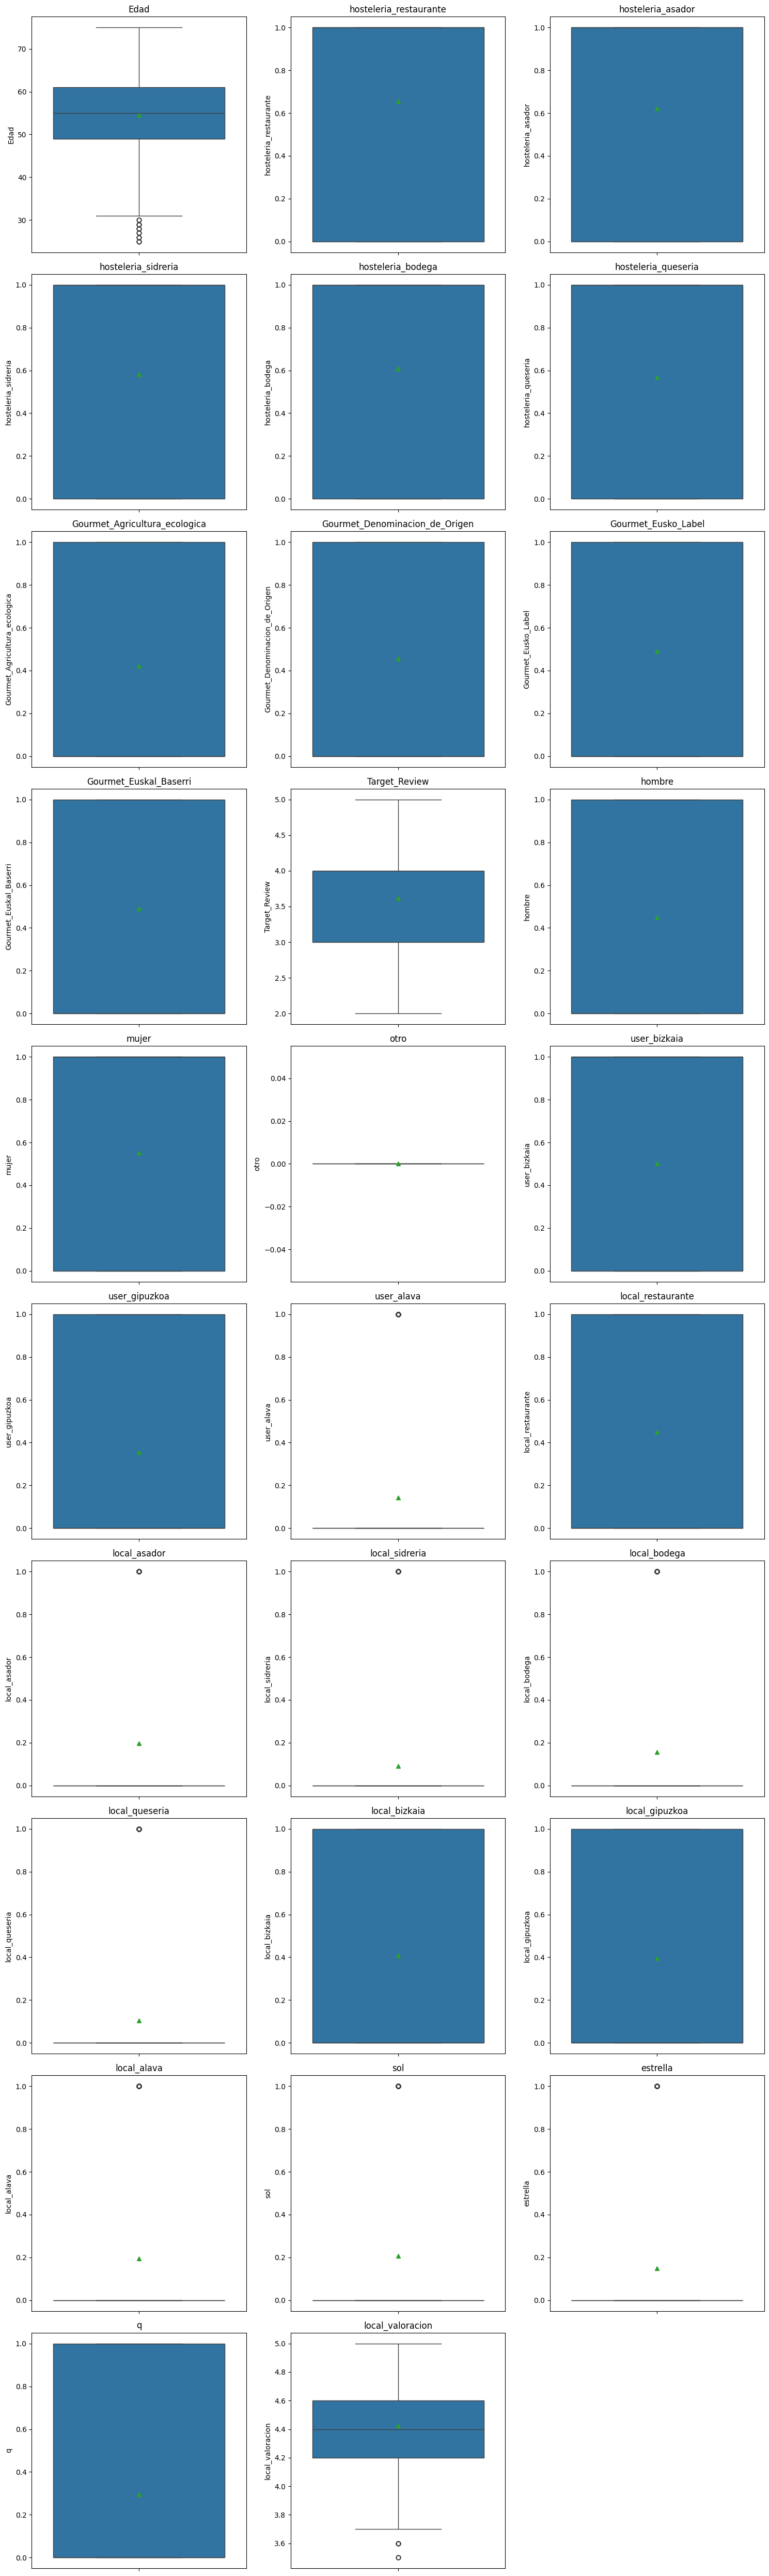

### 📈 Comparación

### (target: Target_Review)

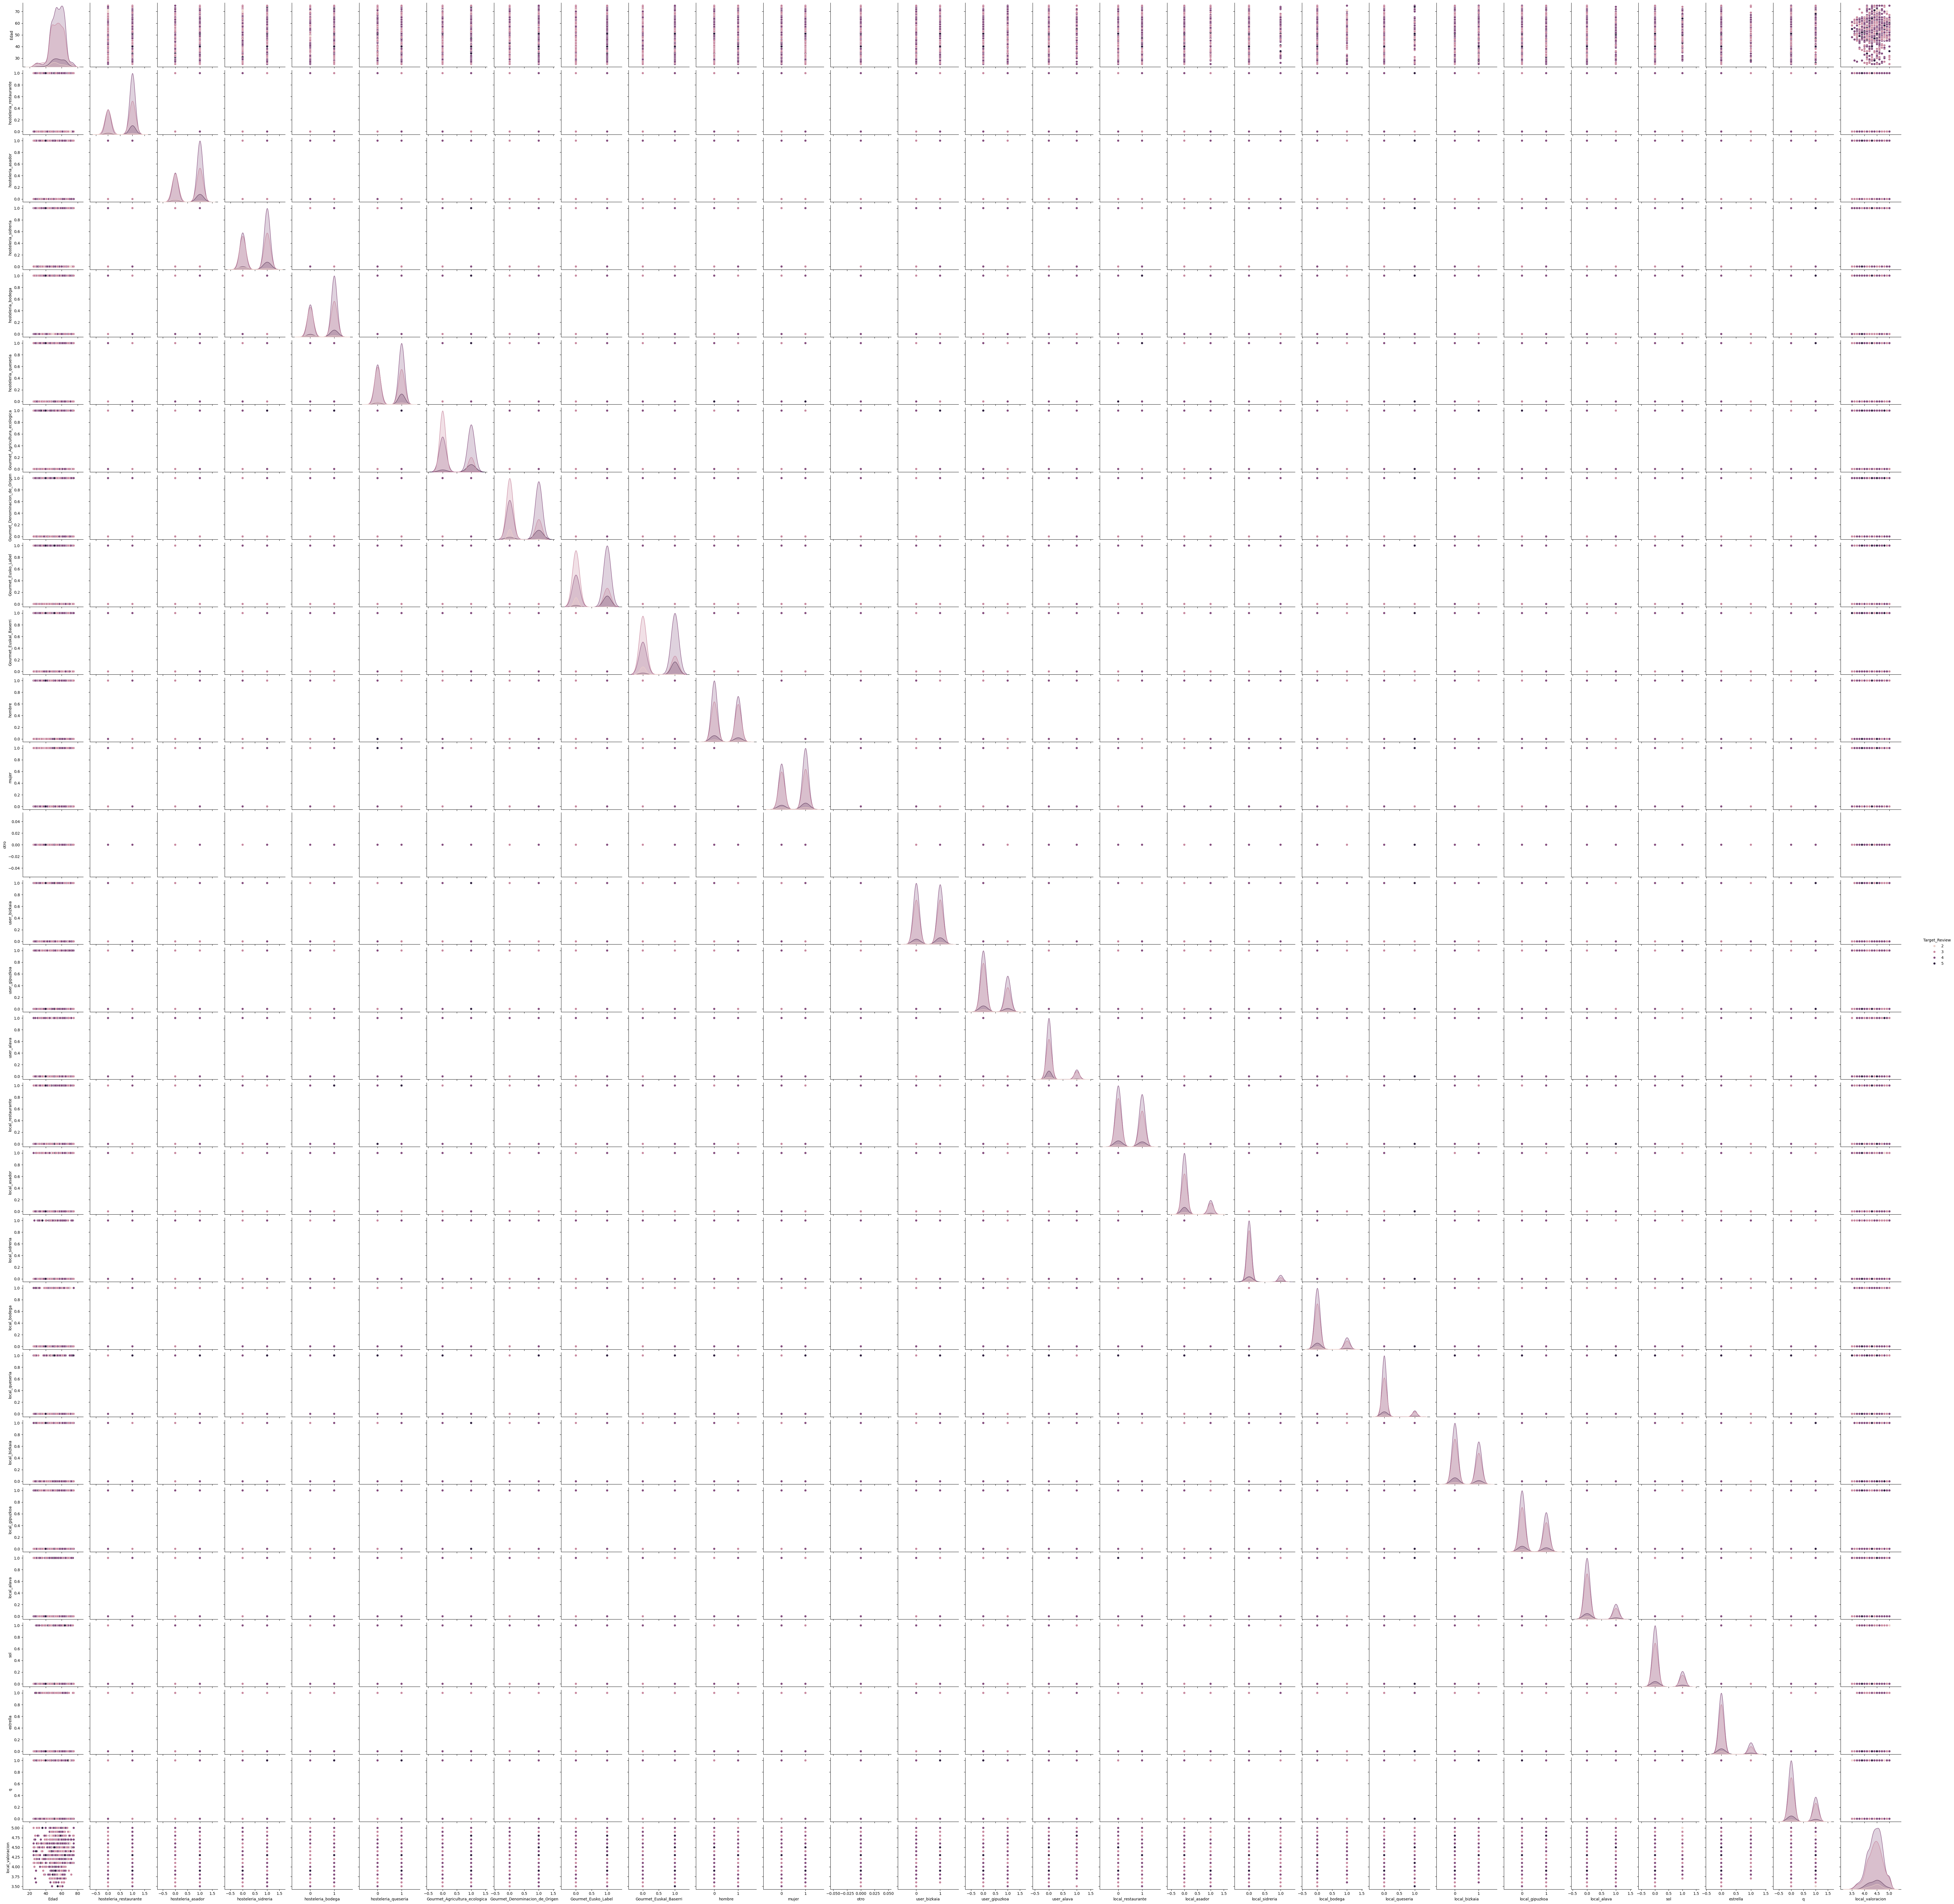

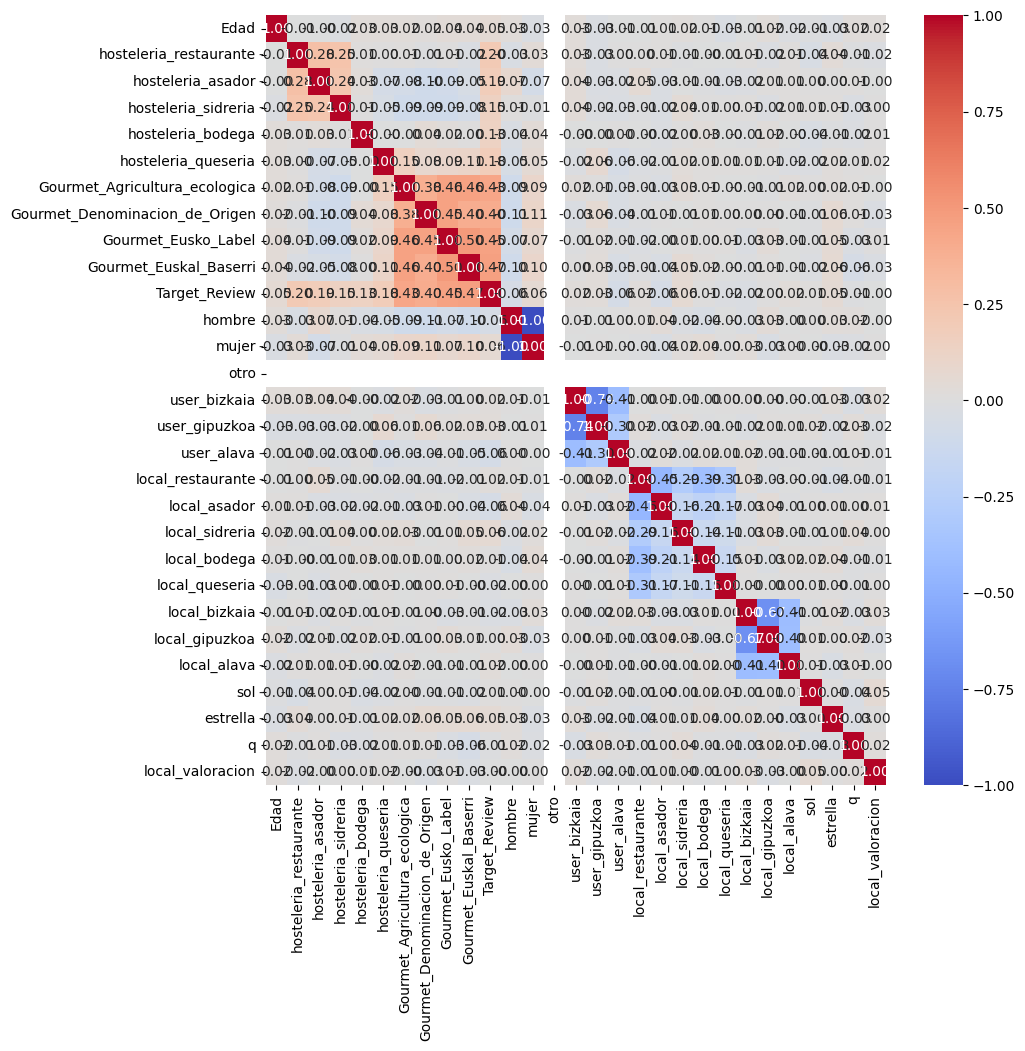

In [5]:
eda(df, target='Target_Review')

In [7]:
X = df.drop(columns=["Target_Review"])
y = df["Target_Review"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
from sklearn.model_selection import GridSearchCV
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)
param_grid = {
    "n_estimators": [200, 500, 800],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2
)

In [27]:
grid_search.fit(X_train, y_train)

print("Best params:")
print(grid_search.best_params_)

print("\nBest score:")
print(-grid_search.best_score_)

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best params:
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 1.0}

Best score:
0.38331185579299926


In [20]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.19),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 1)
}

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

In [24]:
random_search.fit(X_train, y_train)

print(random_search.best_params_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
{'colsample_bytree': np.float64(0.6048617898759265), 'gamma': np.float64(0.969878826707639), 'learning_rate': np.float64(0.018200383270609462), 'max_depth': 7, 'min_child_weight': 6, 'n_estimators': 312, 'subsample': np.float64(0.9971859184477201)}


In [25]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Best params:")
print(random_search.best_params_)

print("\nCV MAE:")
print(-random_search.best_score_)

print("\nTest MAE:")
print(mean_absolute_error(y_test, y_pred))

print("\nTest RMSE:")
print(mean_squared_error(y_test, y_pred))

print("\nTest R²:")
print(r2_score(y_test, y_pred))

Best params:
{'colsample_bytree': np.float64(0.6048617898759265), 'gamma': np.float64(0.969878826707639), 'learning_rate': np.float64(0.018200383270609462), 'max_depth': 7, 'min_child_weight': 6, 'n_estimators': 312, 'subsample': np.float64(0.9971859184477201)}

CV MAE:
0.38154296278953553

Test MAE:
0.38504165410995483

Test RMSE:
0.2582229673862457

Test R²:
0.41471749544143677


In [28]:
import pandas as pd
import matplotlib.pyplot as plt

best_model = random_search.best_estimator_

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

print(importance.head(30))

                           feature  importance
9           Gourmet_Euskal_Baserri    0.329619
8              Gourmet_Eusko_Label    0.148435
6    Gourmet_Agricultura_ecologica    0.076647
7   Gourmet_Denominacion_de_Origen    0.052052
2                hosteleria_asador    0.044363
1           hosteleria_restaurante    0.030183
3              hosteleria_sidreria    0.028907
4                hosteleria_bodega    0.021637
5              hosteleria_queseria    0.018207
16               local_restaurante    0.015630
27                local_valoracion    0.015212
17                    local_asador    0.015119
20                  local_queseria    0.015084
10                          hombre    0.014782
0                             Edad    0.014618
14                   user_gipuzkoa    0.014382
23                     local_alava    0.014034
25                        estrella    0.013743
24                             sol    0.013675
15                      user_alava    0.013458
11           

<Figure size 1000x800 with 0 Axes>

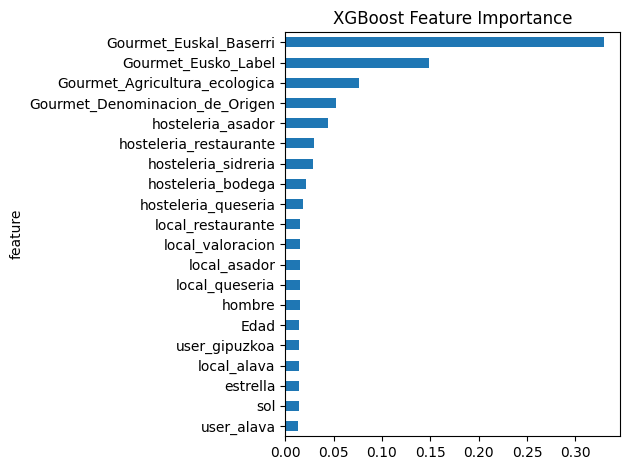

In [29]:
plt.figure(figsize=(10,8))

importance.head(20).sort_values(
    "importance"
).plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False
)

plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
importance.head(15)

,feature,importance
9,Gourmet_Euskal_Baserri,0.329619
8,Gourmet_Eusko_Label,0.148435
6,Gourmet_Agricultura_ecologica,0.076647
7,Gourmet_Denominacion_de_Origen,0.052052
2,hosteleria_asador,0.044363
1,hosteleria_restaurante,0.030183
3,hosteleria_sidreria,0.028907
4,hosteleria_bodega,0.021637
5,hosteleria_queseria,0.018207
16,local_restaurante,0.015630
